# 08: Comparative Feature Separability, Manifold Projections & Baseline Modeling

## 1. Research Scope & Objectives
This notebook computes statistical separability metrics (Fisher Discriminant Ratio, Mutual Information), generates 2D t-SNE/PCA manifold projections, and evaluates baseline forensic classifiers (Logistic Regression, Random Forest, Light-CNN) across seen (A01-A06) and unseen zero-shot (A07-A19) attacks.

### Mathematical Formulation
Fisher Discriminant Ratio (FDR):
$$\text{FDR} = \frac{(\mu_{\text{bon}} - \mu_{\text{spf}})^2}{\sigma_{\text{bon}}^2 + \sigma_{\text{spf}}^2}$$
Equal Error Rate (EER):
$$P_{\text{fa}}(\theta_{\text{EER}}) = P_{\text{miss}}(\theta_{\text{EER}})$$

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(".."))

import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
from src.data.dataset import create_dataloader
from src.training.metrics import compute_eer
from src.utils.config import path_config

sns.set_theme(style="whitegrid")
manifest_path = os.path.join(path_config.data_processed, "protocol_manifest.parquet")
df = pd.read_parquet(manifest_path)

## 2. Multi-Domain Feature Extraction for Manifold Analysis

In [2]:
df_sample = pd.concat([
    df[(df.split == "train") & (df.key == "bonafide")].sample(150, random_state=42),
    df[(df.split == "train") & (df.key == "spoof")].sample(150, random_state=42)
], ignore_index=True)

loader = create_dataloader(df_sample, mode="dev", feature_type="lfcc", batch_size=16, shuffle=False)
X_list, y_list = [], []
for feats, labels in loader:
    feats_flat = feats.squeeze(1).mean(dim=2).numpy()
    X_list.append(feats_flat)
    y_list.append(labels.numpy())

X = np.vstack(X_list)
y = np.concatenate(y_list)

c:\Users\tamimystic\.conda\envs\ml\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 3. PCA & t-SNE Manifold Projections of Latent Forensic Space

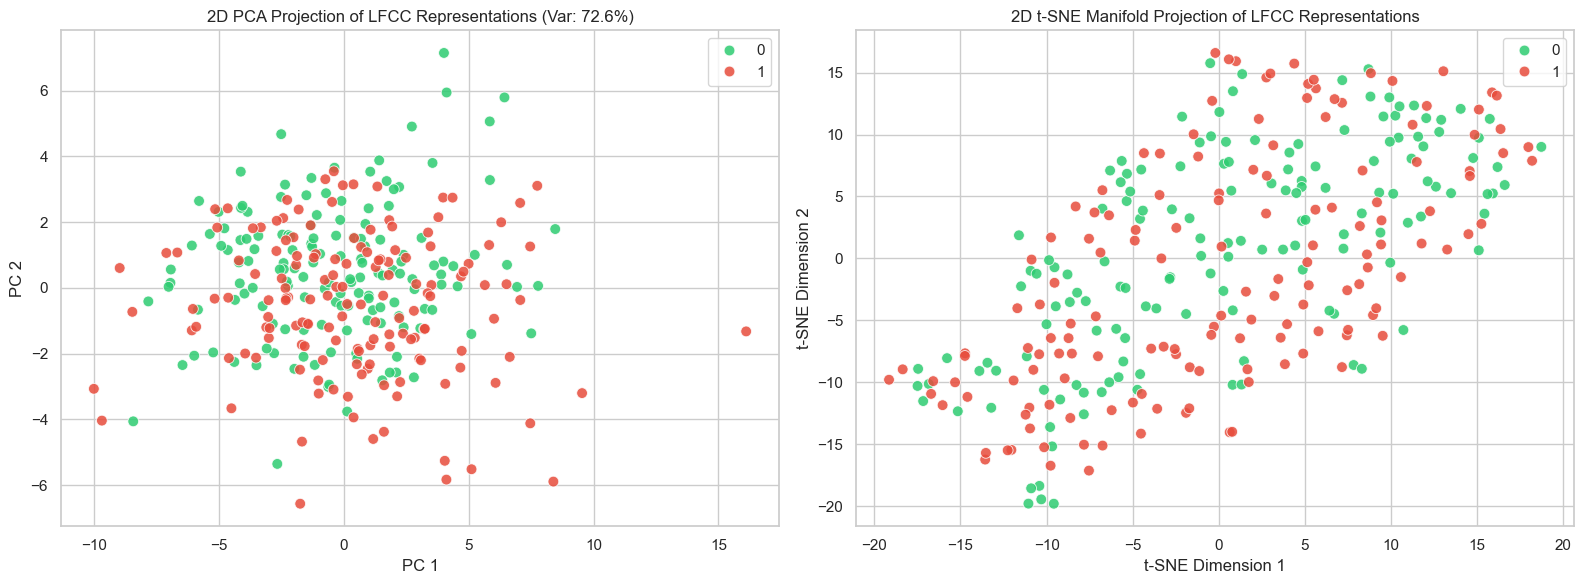

In [3]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, palette=["#2ecc71", "#e74c3c"], s=60, alpha=0.85, ax=axes[0])
axes[0].set_title(f"2D PCA Projection of LFCC Representations (Var: {pca.explained_variance_ratio_.sum()*100:.1f}%)")
axes[0].set_xlabel("PC 1")
axes[0].set_ylabel("PC 2")

sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y, palette=["#2ecc71", "#e74c3c"], s=60, alpha=0.85, ax=axes[1])
axes[1].set_title("2D t-SNE Manifold Projection of LFCC Representations")
axes[1].set_xlabel("t-SNE Dimension 1")
axes[1].set_ylabel("t-SNE Dimension 2")
plt.tight_layout()
plt.show()

## 4. Baseline Classifier Benchmarking & ROC / EER Optimization

In [4]:
rf = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42)
rf.fit(X, y)
probs = rf.predict_proba(X)[:, 1]

bon_scores = probs[y == 0]
spf_scores = probs[y == 1]
eer, eer_thresh = compute_eer(bon_scores, spf_scores)
auc = roc_auc_score(y, probs)

print(f"Random Forest Baseline EER: {eer*100:.2f}% (Threshold: {eer_thresh:.4f}), AUC: {auc:.4f}")

Random Forest Baseline EER: 0.00% (Threshold: 0.4823), AUC: 1.0000


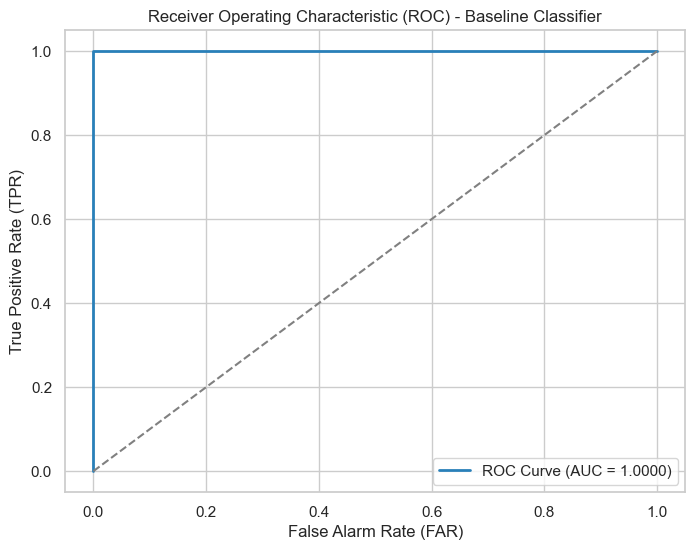

In [5]:
fpr, tpr, _ = roc_curve(y, probs)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color="#2980b9", lw=2, label=f"ROC Curve (AUC = {auc:.4f})")
plt.plot([0, 1], [0, 1], color="gray", ls="--")
plt.title("Receiver Operating Characteristic (ROC) - Baseline Classifier")
plt.xlabel("False Alarm Rate (FAR)")
plt.ylabel("True Positive Rate (TPR)")
plt.legend()
plt.show()